<a href="https://www.kaggle.com/code/sonawanelalitsunil/analyzing-trends-and-insights-in-samsung-mobile?scriptVersionId=224353581" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/samsung-mobile-sales-dataset/Expanded_Dataset.csv


## Project Title:
#### "Analyzing Trends and Insights in Samsung Mobile Sales Data"

## Project Description:
This project focuses on analyzing the Samsung Mobile Sales Dataset to uncover key trends, sales patterns, and factors influencing mobile phone sales. The dataset likely contains information such as product models, sales volumes, revenue, geographic distribution, customer demographics, pricing trends, and seasonal variations.

## Objectives:

Sales Performance Analysis: Identify top-selling Samsung mobile models and their revenue contributions.

Market Trends: Analyze how mobile sales vary across different time periods (seasonality, yearly growth).

Geographical Insights: Determine which regions or countries drive the highest sales.

Customer Preferences: Explore customer choices based on specifications like screen size, battery capacity, and camera quality.

Pricing Impact: Assess how price variations affect sales numbers and revenue.

Competitor Comparison: If applicable, compare Samsung’s sales performance with competitors in the market.

## Approach:

## Data Preprocessing:

Clean missing values, remove duplicates, and standardize formats.

Convert date/time columns for trend analysis.

## Exploratory Data Analysis (EDA):

Visualize sales trends over time using line charts.

Compare product-wise and region-wise performance using bar plots and heatmaps.

Identify correlation between price, features, and sales volume.

## Feature Engineering:

Create new features like discount impact, average revenue per product line, and demand seasonality.

## Import libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Import dataset

In [3]:
df = pd.read_csv("/kaggle/input/samsung-mobile-sales-dataset/Expanded_Dataset.csv")

In [4]:
df.head()

,Year,Quarter,Product Model,5G Capability,Units Sold,Revenue ($),Market Share (%),Regional 5G Coverage (%),5G Subscribers (millions),Avg 5G Speed (Mbps),Preference for 5G (%),Region
0,2019,Q1,Galaxy S10,No,26396,4.212951e+06,1.04,57.36,39.55,293.10,55.87,Asia-Pacific
1,2019,Q1,Galaxy Note10,No,25671,7.240266e+06,2.82,85.80,42.58,67.46,37.26,Latin America
2,2019,Q1,Galaxy S20,No,16573,2.560833e+07,-0.03,47.02,3.78,77.25,84.66,Middle East & Africa
3,2019,Q1,Galaxy Note20,No,7177,2.198442e+07,0.84,25.70,23.41,105.27,40.03,North America
4,2019,Q1,Galaxy S21,No,45633,1.634244e+07,2.36,89.13,44.43,206.17,76.88,Latin America


In [5]:
df.tail()

,Year,Quarter,Product Model,5G Capability,Units Sold,Revenue ($),Market Share (%),Regional 5G Coverage (%),5G Subscribers (millions),Avg 5G Speed (Mbps),Preference for 5G (%),Region
995,2023,Q4,Galaxy S22 5G,Yes,36216,2.995937e+07,3.82,70.59,46.92,177.43,63.86,Latin America
996,2022,Q2,Galaxy S21,No,33806,2.369938e+07,-0.23,77.31,47.51,129.70,78.41,North America
997,2022,Q1,Galaxy S10,No,23678,2.330203e+07,0.58,45.61,43.79,156.56,72.06,Europe
998,2023,Q4,Galaxy Note10,No,35697,1.946256e+07,2.49,36.55,36.44,236.39,47.11,North America
999,2020,Q4,Galaxy Note20,No,7473,1.962177e+07,3.88,74.66,27.55,177.22,72.36,North America


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       1000 non-null   int64  
 1   Quarter                    1000 non-null   object 
 2   Product Model              1000 non-null   object 
 3   5G Capability              1000 non-null   object 
 4   Units Sold                 1000 non-null   int64  
 5   Revenue ($)                1000 non-null   float64
 6   Market Share (%)           1000 non-null   float64
 7   Regional 5G Coverage (%)   1000 non-null   float64
 8   5G Subscribers (millions)  1000 non-null   float64
 9   Avg 5G Speed (Mbps)        1000 non-null   float64
 10  Preference for 5G (%)      1000 non-null   float64
 11  Region                     1000 non-null   object 
dtypes: float64(6), int64(2), object(4)
memory usage: 93.9+ KB


In [7]:
df.describe()

,Year,Units Sold,Revenue ($),Market Share (%),Regional 5G Coverage (%),5G Subscribers (millions),Avg 5G Speed (Mbps),Preference for 5G (%)
count,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,2021.456000,32842.990000,3.019733e+07,3.723570,66.889720,30.152080,179.225560,67.14291
std,1.700281,16039.770572,1.837941e+07,1.991108,19.254095,14.537781,70.470934,15.75925
min,2019.000000,5309.000000,2.987436e+06,-0.490000,25.340000,-0.890000,50.370000,37.14000
25%,2020.000000,19327.250000,1.460749e+07,2.635000,50.400000,18.412500,120.410000,53.26750
50%,2021.000000,33689.000000,2.801200e+07,3.760000,67.050000,29.915000,177.390000,66.96000
75%,2023.000000,43911.000000,4.180391e+07,5.282500,83.210000,44.360000,238.860000,80.99000
max,2024.000000,64883.000000,8.426494e+07,6.950000,103.920000,54.940000,298.700000,94.84000


In [8]:
df.dtypes

Year                           int64
Quarter                       object
Product Model                 object
5G Capability                 object
Units Sold                     int64
Revenue ($)                  float64
Market Share (%)             float64
Regional 5G Coverage (%)     float64
5G Subscribers (millions)    float64
Avg 5G Speed (Mbps)          float64
Preference for 5G (%)        float64
Region                        object
dtype: object

In [9]:
df.shape

(1000, 12)

In [10]:
df.isnull().sum()

Year                         0
Quarter                      0
Product Model                0
5G Capability                0
Units Sold                   0
Revenue ($)                  0
Market Share (%)             0
Regional 5G Coverage (%)     0
5G Subscribers (millions)    0
Avg 5G Speed (Mbps)          0
Preference for 5G (%)        0
Region                       0
dtype: int64

In [11]:
df.columns

Index(['Year', 'Quarter', 'Product Model', '5G Capability', 'Units Sold',
       'Revenue ($)', 'Market Share (%)', 'Regional 5G Coverage (%)',
       '5G Subscribers (millions)', 'Avg 5G Speed (Mbps)',
       'Preference for 5G (%)', 'Region'],
      dtype='object')

## visualization

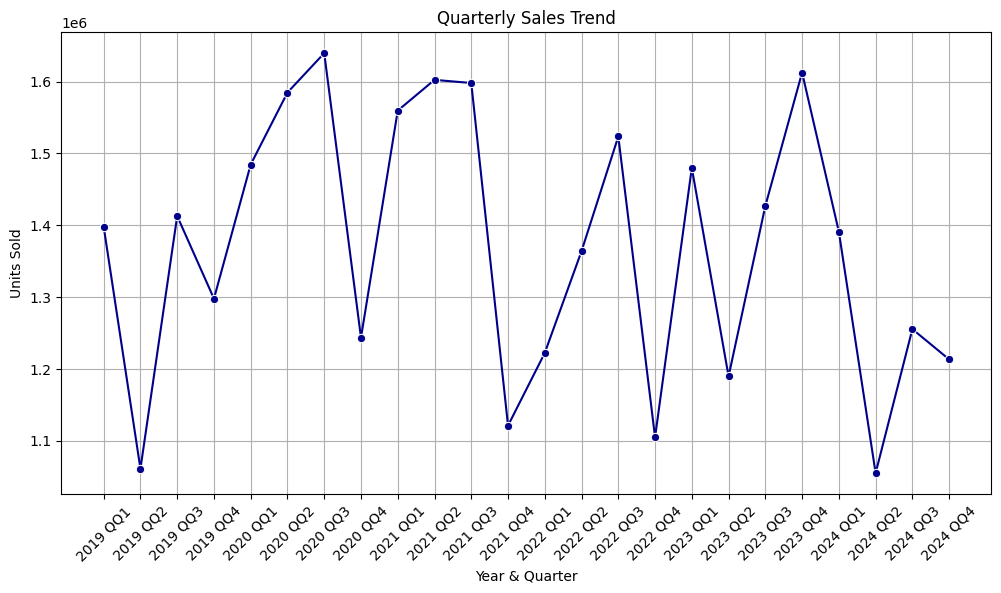

In [12]:
# Grouping data by Year and Quarter
df_sales_trend = df.groupby(['Year', 'Quarter'])['Units Sold'].sum().reset_index()

# Line Plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=df_sales_trend['Year'].astype(str) + ' Q' + df_sales_trend['Quarter'].astype(str),
             y=df_sales_trend['Units Sold'], marker='o', color='darkblue')

plt.xticks(rotation=45)
plt.title('Quarterly Sales Trend')
plt.xlabel('Year & Quarter')
plt.ylabel('Units Sold')
plt.grid(True)
plt.show()

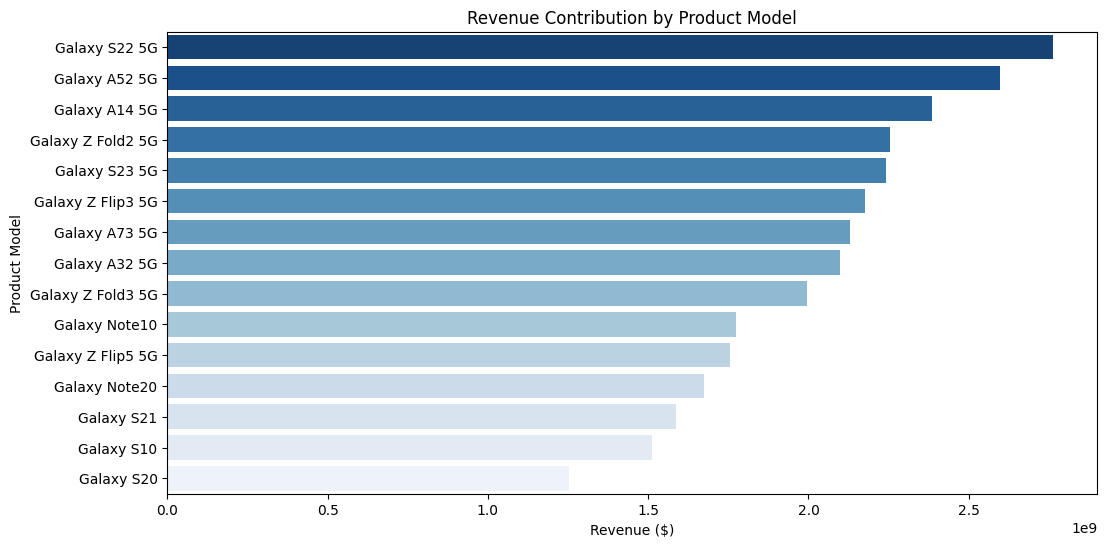

In [13]:
# Summing revenue per product model
df_revenue = df.groupby('Product Model')['Revenue ($)'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Revenue ($)', y='Product Model', data=df_revenue, palette='Blues_r')
plt.title('Revenue Contribution by Product Model')
plt.xlabel('Revenue ($)')
plt.ylabel('Product Model')
plt.show()

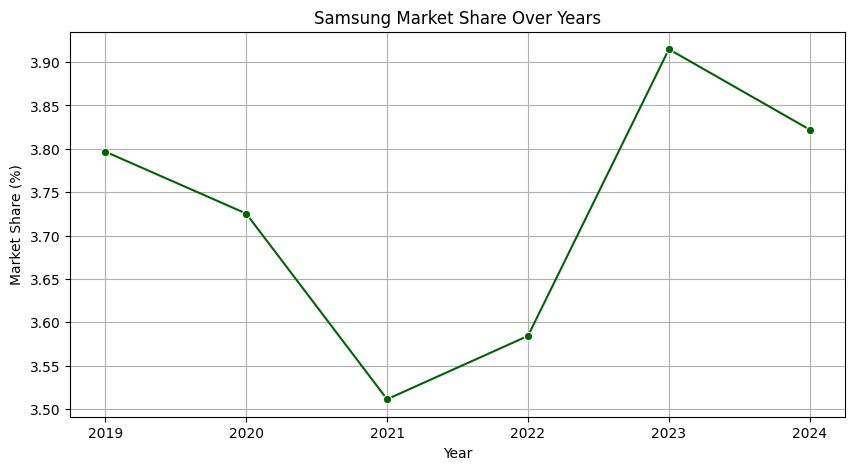

In [14]:
df_market = df.groupby('Year')['Market Share (%)'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x=df_market['Year'], y=df_market['Market Share (%)'], marker='o', color='darkgreen')

plt.title('Samsung Market Share Over Years')
plt.xlabel('Year')
plt.ylabel('Market Share (%)')
plt.grid(True)
plt.show()

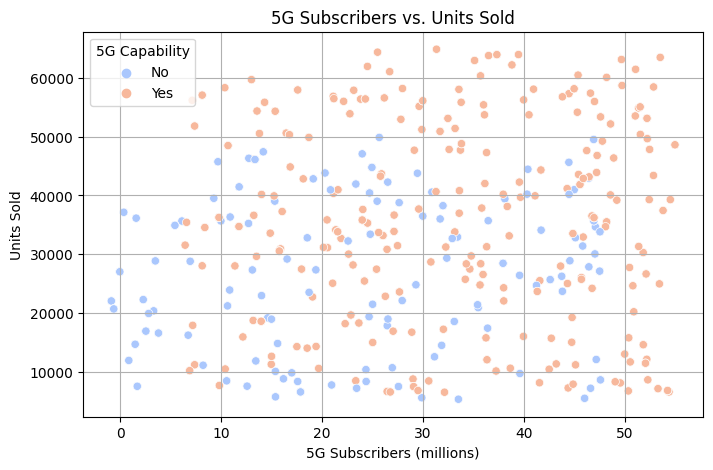

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['5G Subscribers (millions)'], y=df['Units Sold'], hue=df['5G Capability'], palette='coolwarm')

plt.title('5G Subscribers vs. Units Sold')
plt.xlabel('5G Subscribers (millions)')
plt.ylabel('Units Sold')
plt.grid(True)
plt.show()

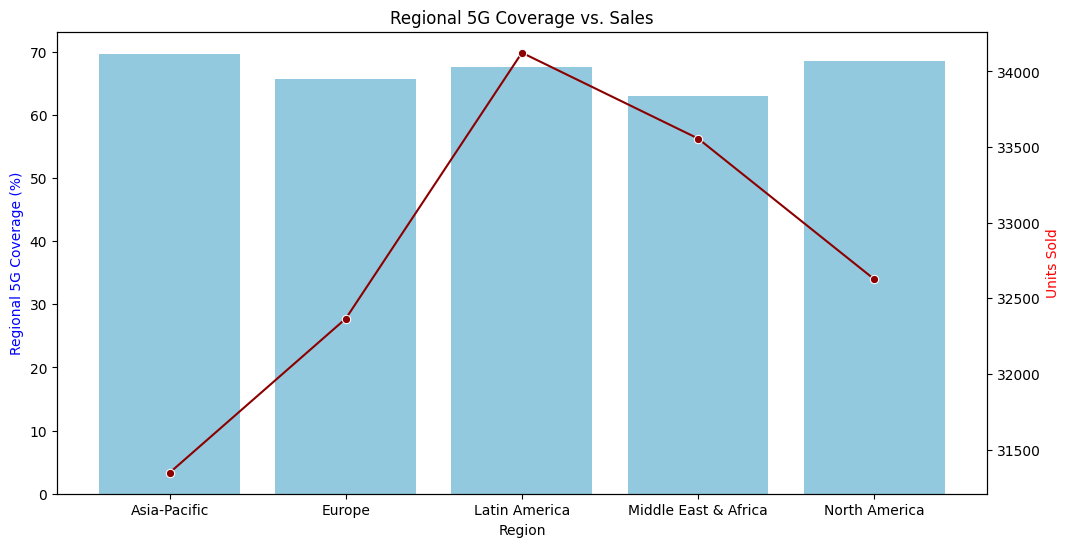

In [16]:
df_region_5g = df.groupby('Region')[['Regional 5G Coverage (%)', 'Units Sold']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(x='Region', y='Regional 5G Coverage (%)', data=df_region_5g, color='skyblue', ax=ax1)

ax2 = ax1.twinx()
sns.lineplot(x='Region', y='Units Sold', data=df_region_5g, marker='o', color='darkred', ax=ax2)

ax1.set_ylabel('Regional 5G Coverage (%)', color='blue')
ax2.set_ylabel('Units Sold', color='red')
plt.title('Regional 5G Coverage vs. Sales')
plt.xticks(rotation=45)
plt.show()

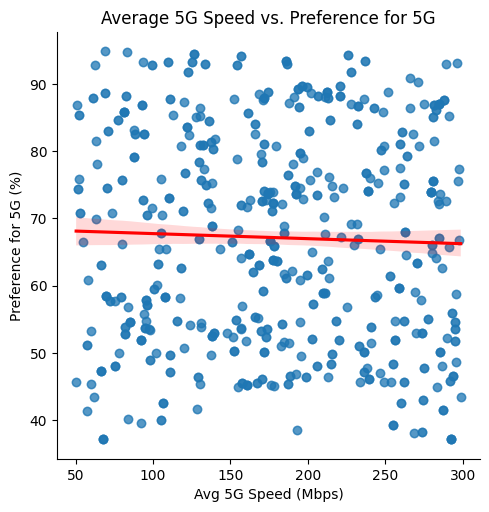

In [17]:
sns.lmplot(x='Avg 5G Speed (Mbps)', y='Preference for 5G (%)', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Average 5G Speed vs. Preference for 5G')
plt.xlabel('Avg 5G Speed (Mbps)')
plt.ylabel('Preference for 5G (%)')
plt.show()

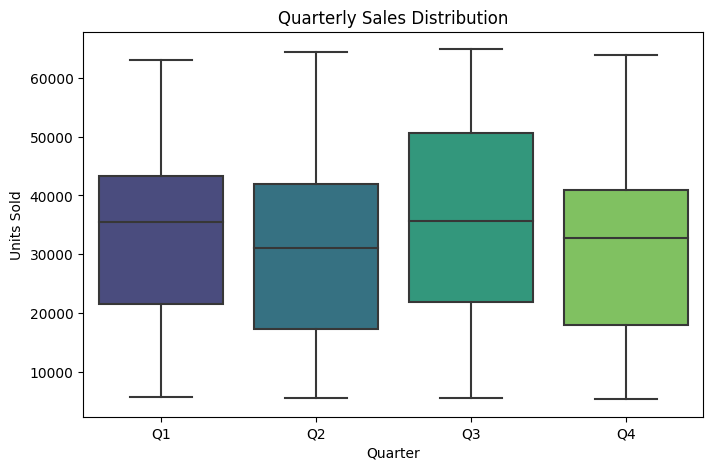

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Quarter', y='Units Sold', data=df, palette='viridis')
plt.title('Quarterly Sales Distribution')
plt.xlabel('Quarter')
plt.ylabel('Units Sold')
plt.show()

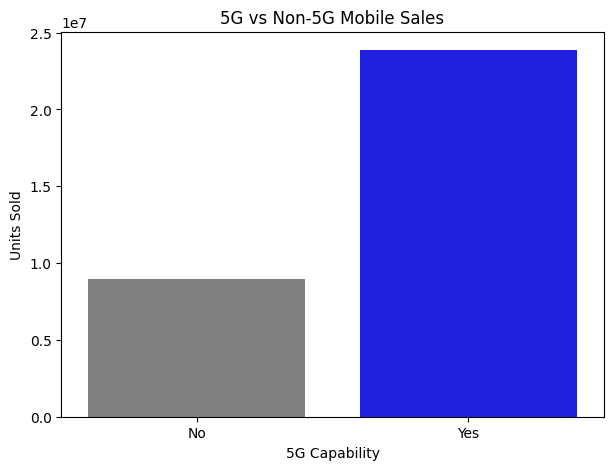

In [19]:
df_5g_sales = df.groupby(['5G Capability'])['Units Sold'].sum().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(x='5G Capability', y='Units Sold', data=df_5g_sales, palette=['gray', 'blue'])
plt.title('5G vs Non-5G Mobile Sales')
plt.xlabel('5G Capability')
plt.ylabel('Units Sold')
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

df = df.copy()

categorical_cols = ['Quarter', 'Product Model', '5G Capability', 'Region']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Save encoder for future use
X = df.drop(columns=['Revenue ($)'])  # Drop target variable
y = df['Revenue ($)']  # Predicting revenue
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "Support Vector Machine": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "XGBoost": XGBRegressor(objective='reg:squarederror', random_state=42),
    "LightGBM": LGBMRegressor(),
    "CatBoost": CatBoostRegressor(verbose=0)  # Silent training
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)  # Train model
    y_pred = model.predict(X_test)  # Make predictions
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append((name, mae, r2))
results_df = pd.DataFrame(results, columns=["Model", "MAE", "R² Score"])
results_df = results_df.sort_values(by="R² Score", ascending=False)
print(results_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002824 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1481
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 11
[LightGBM] [Info] Start training from score 30399190.018750
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

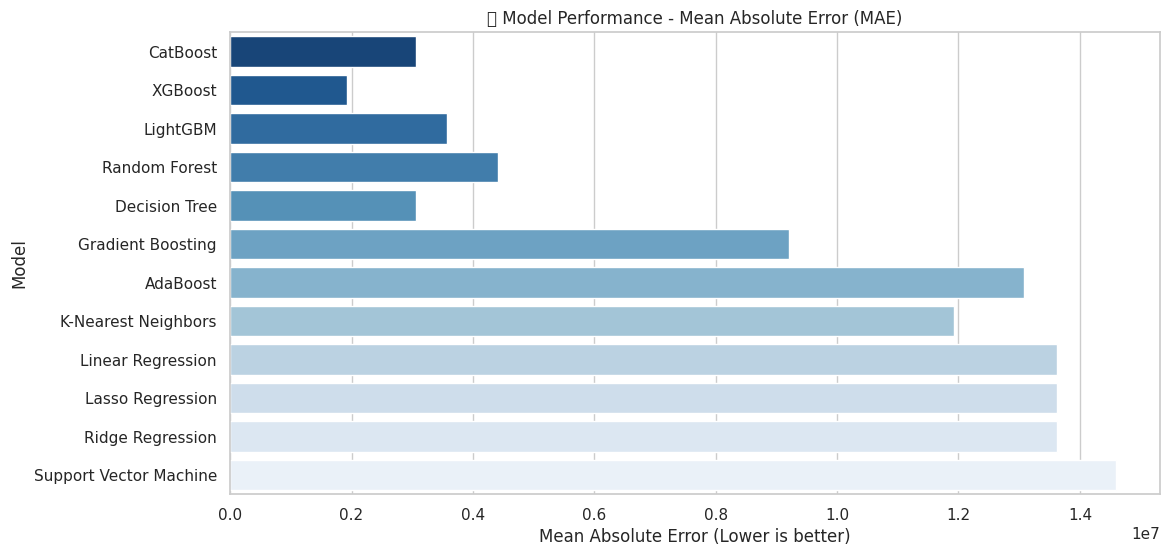

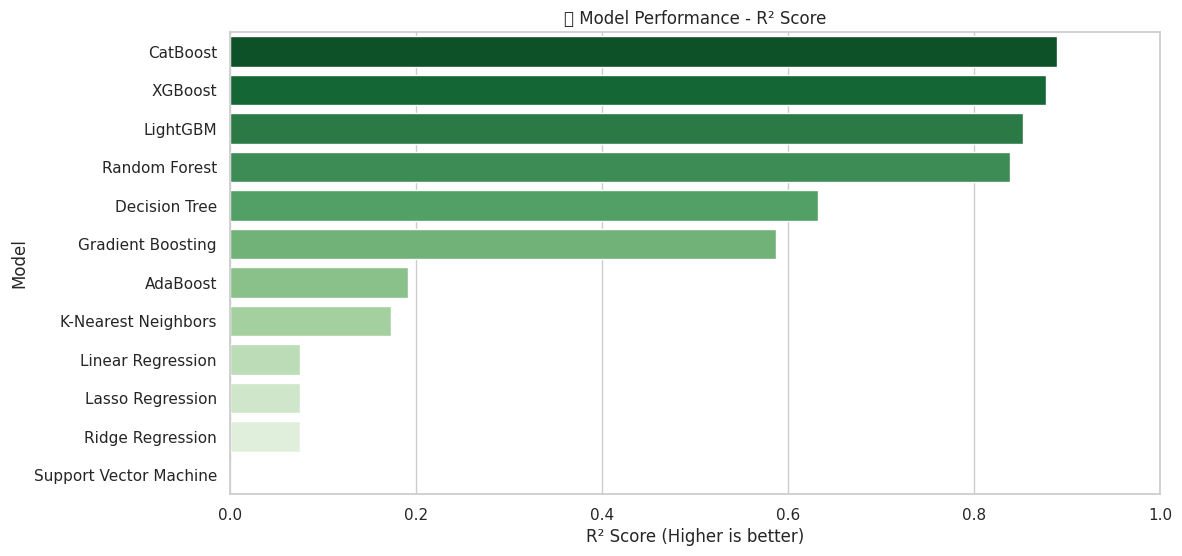

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Sort models by R² Score
results_df = results_df.sort_values(by="R² Score", ascending=False)

# 🔹 Visualization 1: MAE Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x="MAE", y="Model", data=results_df, palette="Blues_r")
plt.xlabel("Mean Absolute Error (Lower is better)")
plt.ylabel("Model")
plt.title("📉 Model Performance - Mean Absolute Error (MAE)")
plt.show()

# 🔹 Visualization 2: R² Score Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x="R² Score", y="Model", data=results_df, palette="Greens_r")
plt.xlabel("R² Score (Higher is better)")
plt.ylabel("Model")
plt.title("📈 Model Performance - R² Score")
plt.xlim(0, 1)  # R² score ranges from 0 to 1
plt.show()


## Thank you....pls Upvote..!!!!